In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!nvidia-smi

Mon May 25 12:04:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# IMPORT LIBRARIES
# =========================================================
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import VGG16_Weights

In [4]:
# PATHS
# =========================================================
TRAIN_PATH = "/content/drive/MyDrive/final project/data/fashion-mnist_train.csv" # Please ensure this path is correct
TEST_PATH  = "/content/drive/MyDrive/final project/data/fashion-mnist_test.csv" # Please ensure this path is correct

FEATURE_DIR = "/content/drive/MyDrive/final project/saved_features"
MODEL_DIR   = "/content/drive/MyDrive/final project/saved_models"

os.makedirs(FEATURE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

In [5]:
# CLASS NAMES
# =========================================================
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

NUM_CLASSES = len(CLASS_NAMES)


In [6]:
# DEVICE
# =========================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using Device: {DEVICE}")


Using Device: cuda


In [7]:
# IMAGE TRANSFORMS
# =========================================================
train_transform = transforms.Compose([

    # RESIZE IMAGE
    transforms.Resize((224, 224)),

    # DATA AUGMENTATION (Good practice for training)
    transforms.RandomHorizontalFlip(),

    # CONVERT TO TENSOR
    transforms.ToTensor(),

    # NORMALIZATION (Standard for ImageNet pre-trained models)
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])


In [8]:
# CUSTOM DATASET
# =========================================================
class FashionMNISTDataset(Dataset):

    def __init__(self, csv_file, transform=None):

        self.data = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        # LABEL
        label = int(self.data.iloc[idx, 0])

        # IMAGE PIXELS
        pixels = self.data.iloc[idx, 1:].values.astype(np.uint8)

        # CONVERT TO IMAGE
        image = Image.fromarray(
            pixels.reshape(28, 28).astype(np.uint8)
        ).convert("RGB")

        # APPLY TRANSFORM
        if self.transform:
            image = self.transform(image)

        return image, label


In [9]:
# CREATE DATASETS
# =========================================================
train_dataset = FashionMNISTDataset(
    TRAIN_PATH,
    transform=train_transform
)

test_dataset = FashionMNISTDataset(
    TEST_PATH,
    transform=test_transform
)


In [10]:
# DATALOADERS
# =========================================================
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [11]:
# LOAD PRETRAINED VGG16 MODEL
# =========================================================
vgg_model = models.vgg16(
    weights=VGG16_Weights.IMAGENET1K_V1
)

# =========================================================
# FREEZE PRETRAINED LAYERS
# =========================================================
for param in vgg_model.parameters():
    param.requires_grad = False

# =========================================================
# MODIFY FINAL CLASSIFIER
# =========================================================
vgg_model.classifier[6] = nn.Linear(
    vgg_model.classifier[6].in_features,
    NUM_CLASSES
)

vgg_model = vgg_model.to(DEVICE)

print("\nVGG16 Model Loaded Successfully")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 152MB/s]



VGG16 Model Loaded Successfully


In [12]:
# =========================================================
# LOSS FUNCTION
# =========================================================
criterion = nn.CrossEntropyLoss()

# =========================================================
# OPTIMIZER
# =========================================================
optimizer = optim.Adam(
    vgg_model.classifier[6].parameters(),
    lr=0.001
)


In [13]:
# FEATURE EXTRACTION FUNCTION
# =========================================================
def extract_and_save_features(
    model,
    loader,
    save_path
):

    print(f"\nExtracting Features -> {save_path}")

    model.eval()

    features_list = []
    labels_list = []

    feature_extractor = model.features
    feature_extractor = feature_extractor.to(DEVICE)

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(DEVICE)

            # EXTRACT FEATURES
            features = feature_extractor(images)

            # FLATTEN FEATURES
            features = features.view(features.size(0), -1)

            features_list.append(
                features.cpu().numpy()
            )

            labels_list.append(
                labels.numpy()
            )

    # CONCATENATE FEATURES
    features_array = np.concatenate(features_list, axis=0)
    labels_array   = np.concatenate(labels_list, axis=0)

    # SAVE FEATURES
    np.savez(
        save_path,
        features=features_array,
        labels=labels_array
    )

    print("\nFeatures Saved Successfully")
    print("Feature Shape:", features_array.shape)


In [ ]:
# EXTRACT + SAVE FEATURES
# =========================================================
extract_and_save_features(
    vgg_model,
    train_loader,
    os.path.join(
        FEATURE_DIR,
        "vgg_train_features.npz"
    )
)

extract_and_save_features(
    vgg_model,
    test_loader,
    os.path.join(
        FEATURE_DIR,
        "vgg_test_features.npz"
    )
)



Extracting Features -> /content/drive/MyDrive/final project/saved_features/vgg_train_features.npz


100%|██████████| 938/938 [07:04<00:00,  2.21it/s]


In [14]:
# TRAINING
# =========================================================
train_losses = []
train_accuracies = []

EPOCHS = 10

print("\nTraining VGG16 Model...\n")

for epoch in range(EPOCHS):

    vgg_model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        # ZERO GRADIENTS
        optimizer.zero_grad()

        # FORWARD PASS
        outputs = vgg_model(images)

        # LOSS
        loss = criterion(outputs, labels)

        # BACKPROPAGATION
        loss.backward()

        # UPDATE WEIGHTS
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        # PREDICTIONS
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()

        total += labels.size(0)

    # EPOCH METRICS
    epoch_loss = total_loss / total
    epoch_acc  = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(
        f"\nEpoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_acc:.4f}"
    )



Training VGG16 Model...



100%|██████████| 938/938 [07:15<00:00,  2.15it/s]



Epoch [1/10] Loss: 0.5232 Accuracy: 0.8189


100%|██████████| 938/938 [07:13<00:00,  2.16it/s]



Epoch [2/10] Loss: 0.5255 Accuracy: 0.8185


...


Epoch [8/10] Loss: 0.5260 Accuracy: 0.8205


100%|██████████| 938/938 [07:14<00:00,  2.16it/s]



Epoch [9/10] Loss: 0.5240 Accuracy: 0.8215


100%|██████████| 938/938 [07:16<00:00,  2.15it/s]


Epoch [10/10] Loss: 0.5238 Accuracy: 0.8214


In [15]:
# SAVE MODEL
# =========================================================
MODEL_SAVE_PATH = os.path.join(
    MODEL_DIR,
    "vgg16_fashionmnist.pth"
)

torch.save(
    vgg_model.state_dict(),
    MODEL_SAVE_PATH
)

print("\nVGG16 Model Saved Successfully")
print(f"Saved Path: {MODEL_SAVE_PATH}")



VGG16 Model Saved Successfully
Saved Path: /content/drive/MyDrive/final project/saved_models/vgg16_fashionmnist.pth


In [16]:
# EVALUATION
# =========================================================
vgg_model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = vgg_model(images)

        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total

print(f"\nTest Accuracy: {test_accuracy:.4f}")


100%|██████████| 157/157 [01:11<00:00,  2.20it/s]


Test Accuracy: 0.8615


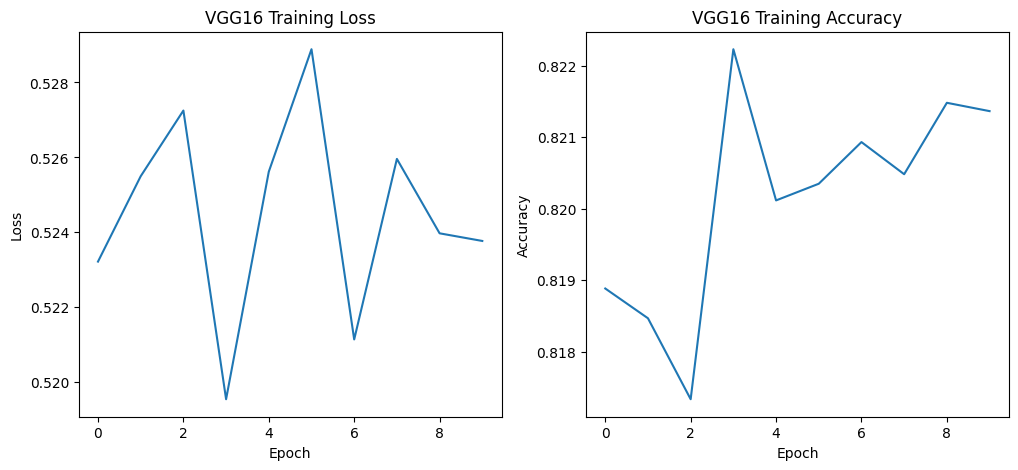

In [22]:
# PLOT TRAINING RESULTS
# ============================================
plt.figure(figsize=(12, 5))

# LOSS GRAPH
plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title("VGG16 Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# ACCURACY GRAPH
plt.subplot(1, 2, 2)
plt.plot(train_accuracies)
plt.title("VGG16 Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()